# 03 — Modeling: LightGBM PD Champion

**Goal:** train a calibrated LightGBM model that outputs a Probability of Default in `[0, 1]`, validated with the credit-risk metric suite (PR-AUC, ROC-AUC, KS, Brier, Gini).

Approach:
1. Load `outputs/features.parquet`, split X/y, identify categorical columns.
2. 5-fold stratified CV, LightGBM with `scale_pos_weight = 11.39`, early stopping on validation PR-AUC.
3. Report per-fold metrics + out-of-fold (OOF) predictions.
4. Isotonic calibration on the OOF predictions (so the score is a probability, not a ranking).
5. Refit on full training data with the median best-iteration; save model + calibrator + OOF scores.

No SMOTE, no undersampling: `scale_pos_weight` handles imbalance and preserves calibration.

In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedKFold

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import OUTPUTS_DIR, RANDOM_STATE, credit_risk_metrics

pd.set_option("display.max_columns", 50)

## 1. Load features and split X / y

In [2]:
features = pd.read_parquet(OUTPUTS_DIR / "features.parquet")
print(f"Loaded {features.shape}")

y = features["TARGET"].astype(int)
drop_cols = ["TARGET", "SK_ID_CURR"]
X = features.drop(columns=drop_cols)

cat_cols = X.select_dtypes(include=["category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
print(f"X shape: {X.shape}  |  numeric: {len(num_cols)}  |  categorical: {len(cat_cols)}")
print(f"Positive rate: {y.mean():.4f}")

base_rate = y.mean()
scale_pos_weight = (1 - base_rate) / base_rate
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Loaded (307511, 241)
X shape: (307511, 239)  |  numeric: 223  |  categorical: 16
Positive rate: 0.0807
scale_pos_weight: 11.39


## 2. LightGBM hyperparameters

Settings tuned for tabular credit data: moderate depth, strong regularization, large `min_child_samples` to prevent overfitting on the imbalanced minority class. PR-AUC chosen as the early-stopping metric — it's what we'd optimize in production.

In [3]:
params = {
    "objective": "binary",
    "metric": "average_precision",  # PR-AUC
    "learning_rate": 0.05,           # quick mode: bigger steps (was 0.02)
    "num_leaves": 31,                # quick mode: simpler trees (was 63)
    "max_depth": -1,
    "min_child_samples": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "scale_pos_weight": scale_pos_weight,
    "verbosity": -1,
    "seed": RANDOM_STATE,
    "n_jobs": -1,
}
NUM_BOOST_ROUND = 1000   # quick mode (was 3000)
EARLY_STOPPING = 50      # quick mode (was 100)

## 3. 5-fold stratified CV

In [4]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)   # quick mode: 3 folds (was 5)
oof = np.zeros(len(X))
fold_metrics = []
best_iters = []
feature_importances = pd.DataFrame(index=X.columns)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    dtrain = lgb.Dataset(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=cat_cols)
    dvalid = lgb.Dataset(X.iloc[va_idx], y.iloc[va_idx], categorical_feature=cat_cols, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        valid_sets=[dvalid],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    raw = model.predict(X.iloc[va_idx], num_iteration=model.best_iteration)
    oof[va_idx] = raw
    best_iters.append(model.best_iteration)
    metrics = credit_risk_metrics(y.iloc[va_idx].values, raw)
    metrics["fold"] = fold
    metrics["best_iter"] = model.best_iteration
    fold_metrics.append(metrics)
    feature_importances[f"fold_{fold}"] = pd.Series(
        model.feature_importance(importance_type="gain"), index=X.columns
    )
    print(
        f"Fold {fold} | best_iter={model.best_iteration:>4} | "
        f"PR-AUC={metrics['pr_auc']:.4f} | ROC-AUC={metrics['roc_auc']:.4f} | "
        f"KS={metrics['ks']:.4f} | Brier={metrics['brier']:.4f}"
    )

Fold 1 | best_iter= 197 | PR-AUC=0.2596 | ROC-AUC=0.7705 | KS=0.4070 | Brier=0.1815


Fold 2 | best_iter= 248 | PR-AUC=0.2592 | ROC-AUC=0.7724 | KS=0.4083 | Brier=0.1790


Fold 3 | best_iter= 405 | PR-AUC=0.2589 | ROC-AUC=0.7694 | KS=0.4071 | Brier=0.1701


## 4. Aggregate fold metrics + OOF metrics

In [5]:
metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
print("Per-fold metrics:")
print(metrics_df.round(4))
print("\nMean +/- std across folds:")
summary = metrics_df.drop(columns=["best_iter"]).agg(["mean", "std"]).T
print(summary.round(4))

oof_metrics = credit_risk_metrics(y.values, oof)
print("\nOut-of-fold metrics (the honest, leak-free assessment):")
for k, v in oof_metrics.items():
    print(f"  {k:>8s}: {v:.4f}")

Per-fold metrics:
      pr_auc  roc_auc    gini      ks   brier  best_iter
fold                                                    
1     0.2596   0.7705  0.5409  0.4070  0.1815        197
2     0.2592   0.7724  0.5448  0.4083  0.1790        248
3     0.2589   0.7694  0.5387  0.4071  0.1701        405

Mean +/- std across folds:
           mean     std
pr_auc   0.2592  0.0003
roc_auc  0.7707  0.0015
gini     0.5415  0.0031
ks       0.4075  0.0007
brier    0.1769  0.0060



Out-of-fold metrics (the honest, leak-free assessment):
    pr_auc: 0.2586
   roc_auc: 0.7705
      gini: 0.5410
        ks: 0.4062
     brier: 0.1769


## 5. Isotonic calibration on OOF scores

Because we trained with `scale_pos_weight`, the raw scores are well-ranked but not calibrated probabilities — they're biased high. Isotonic regression on the leak-free OOF scores produces a monotonic mapping `raw_score -> PD` that we can ship.

In [6]:
calibrator = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
calibrator.fit(oof, y.values)
oof_calibrated = calibrator.predict(oof)

calibrated_metrics = credit_risk_metrics(y.values, oof_calibrated)
print("Calibrated OOF metrics:")
for k, v in calibrated_metrics.items():
    print(f"  {k:>8s}: {v:.4f}")

# Brier should drop; ranking metrics (PR-AUC, ROC-AUC, KS) should be unchanged (isotonic is monotonic)
print("\nBrier improvement from calibration:")
print(f"  raw      = {oof_metrics['brier']:.4f}")
print(f"  isotonic = {calibrated_metrics['brier']:.4f}")

# Reliability check: mean predicted PD should match the observed default rate
print(f"\nMean raw OOF score:        {oof.mean():.4f}")
print(f"Mean calibrated OOF score: {oof_calibrated.mean():.4f}")
print(f"Actual default rate:       {y.mean():.4f}")

Calibrated OOF metrics:
    pr_auc: 0.2537
   roc_auc: 0.7709
      gini: 0.5418
        ks: 0.4069
     brier: 0.0670

Brier improvement from calibration:
  raw      = 0.1769
  isotonic = 0.0670

Mean raw OOF score:        0.3772
Mean calibrated OOF score: 0.0807
Actual default rate:       0.0807


## 6. Reliability diagram (decile bins)

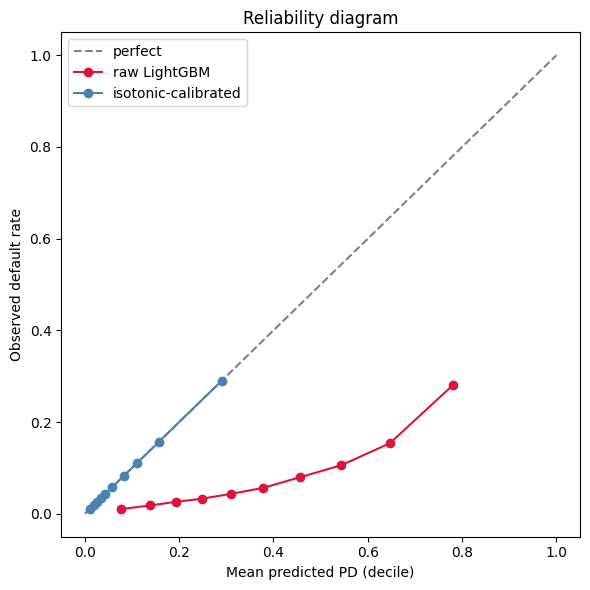

In [7]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

frac_pos_raw, mean_pred_raw = calibration_curve(y, oof, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y, oof_calibrated, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
ax.plot(mean_pred_raw, frac_pos_raw, "o-", label="raw LightGBM", color="crimson")
ax.plot(mean_pred_cal, frac_pos_cal, "o-", label="isotonic-calibrated", color="steelblue")
ax.set_xlabel("Mean predicted PD (decile)")
ax.set_ylabel("Observed default rate")
ax.set_title("Reliability diagram")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "reliability.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Top features by mean gain

In [8]:
feature_importances["mean_gain"] = feature_importances.mean(axis=1)
top20 = feature_importances.sort_values("mean_gain", ascending=False).head(20)
print("Top 20 features by mean gain across folds:")
print(top20[["mean_gain"]].round(1))

Top 20 features by mean gain across folds:
                      mean_gain
EXT_SOURCE_MEAN        377479.2
ORGANIZATION_TYPE      149151.5
CREDIT_ANNUITY_RATIO    63593.5
CREDIT_GOODS_RATIO      29886.6
OCCUPATION_TYPE         26595.5
EXT_SOURCE_MIN          24131.9
EXT_SOURCE_3            22403.2
EXT_SOURCE_1            16770.8
AMT_ANNUITY             16103.0
OWN_CAR_AGE             15341.4
AMT_GOODS_PRICE         14166.3
EXT_SOURCE_MAX          14160.2
EMPLOYED_AGE_RATIO      13911.6
NAME_EDUCATION_TYPE     13072.8
DAYS_BIRTH              12517.9
CODE_GENDER             10780.1
DAYS_ID_PUBLISH         10763.3
EXT_SOURCE_2            10673.2
AGE_YEARS                9856.1
DAYS_EMPLOYED            9640.6


## 8. Refit champion on full data + persist artifacts

In [9]:
final_rounds = int(np.median(best_iters))
print(f"Refitting on full data with {final_rounds} rounds (median of fold best_iters {best_iters})")

dtrain_full = lgb.Dataset(X, y, categorical_feature=cat_cols)
champion = lgb.train(params, dtrain_full, num_boost_round=final_rounds)

artifacts = {
    "model": champion,
    "calibrator": calibrator,
    "feature_names": X.columns.tolist(),
    "categorical_features": cat_cols,
    "params": params,
    "best_iteration": final_rounds,
    "oof_metrics": oof_metrics,
    "calibrated_oof_metrics": calibrated_metrics,
    "fold_metrics": fold_metrics,
}
joblib.dump(artifacts, OUTPUTS_DIR / "champion.joblib")

# Persist OOF for later interpretability / threshold analysis
pd.DataFrame({
    "SK_ID_CURR": features["SK_ID_CURR"].values,
    "TARGET": y.values,
    "oof_raw": oof,
    "oof_pd": oof_calibrated,
}).to_parquet(OUTPUTS_DIR / "oof_predictions.parquet", index=False)

feature_importances.to_csv(OUTPUTS_DIR / "feature_importance.csv")

print(f"\nSaved:")
for p in ["champion.joblib", "oof_predictions.parquet", "reliability.png", "feature_importance.csv"]:
    path = OUTPUTS_DIR / p
    print(f"  {p:<28s} ({path.stat().st_size / 1024:.1f} KB)")

Refitting on full data with 248 rounds (median of fold best_iters [197, 248, 405])



Saved:
  champion.joblib              (900.5 KB)
  oof_predictions.parquet      (4441.6 KB)
  reliability.png              (41.5 KB)
  feature_importance.csv       (21.0 KB)
